In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

In [2]:
import importlib
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import monk_common as mc
import knn_common as kc
import cross_common as cr

In [3]:
importlib.reload(mc)
importlib.reload(kc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [4]:
# Split for KFold
default_cv = cr.common_fold_strategy(stratified=True) #cc StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)
default_krange = list(range(1, 41, 2))
default_scoring = cr.common_scoring("acc")

default_pipe = Pipeline([
    ("model", KNeighborsClassifier())
])

default_param_grid = {
    "model__n_neighbors": default_krange,
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
    "model__metric": ["minkowski"]
}


<h2>Exploring Datasets</h2>
<hr/>

<h3>Monk 1</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [5]:
monk_1_TR_orig, monk_1_TS_orig = mc.load_set(1)
X_tr_1, y_tr_1 = mc.split_and_prepare_dataset(monk_1_TR_orig)
X_ts_1, y_ts_1 = mc.split_and_prepare_dataset(monk_1_TS_orig)
mc.dataset_introspection(monk_1_TR_orig, monk_1_TS_orig)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

<h5>Training</h5>
<p>Search for the best hyperparameters with grid search.</p>

In [6]:
scoring_1 = cr.common_scoring("acc")
gs_1 = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=scoring_1,
    cv=default_cv,
    n_jobs=-1,
    return_train_score=True
)

gs_1.fit(X_tr_1, y_tr_1)
best_estimator_1 = gs_1.best_estimator_
model_1, best_params = cr.extract_best_pipeline_metrics_from_grid(gs_1)
cr.grid_introspection(gs_1)

Total model explored: 80
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'}
Best score: 0.7983333333333333
Best model: Pipeline(steps=[('model',
                 KNeighborsClassifier(n_neighbors=7, p=1, weights='distance'))])


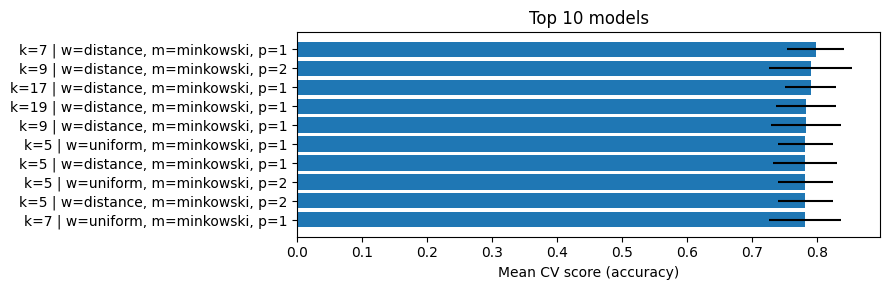

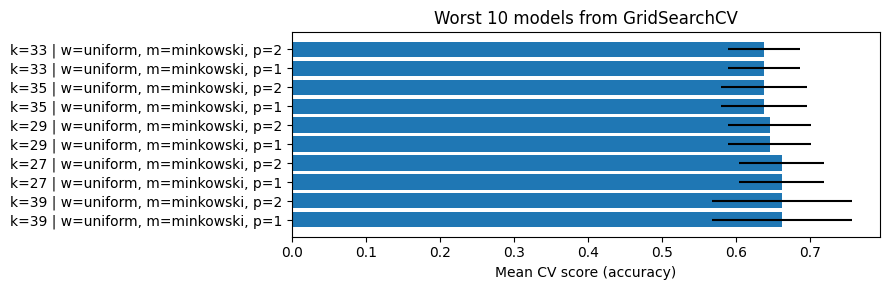

In [7]:
cr.plot_top_models(gs_1.cv_results_, label_row=kc.label_row,scoring_name=scoring_1)

<h5>Validation Curve</h5>
<p>In this plot we analyze the effect of the neighborhood size k on the performance of the K-Nearest Neighbors classifier.
For each value of k, the model accuracy is estimated using cross-validation, allowing us to study how model complexity influences generalization performance.
Formally, accuracy is defined as:
</p>
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\big(\hat{y}_i = y_i\big)$$
<p>
The validation curve highlights the bias–variance trade-off of the KNN classifier as k varies.
</p>

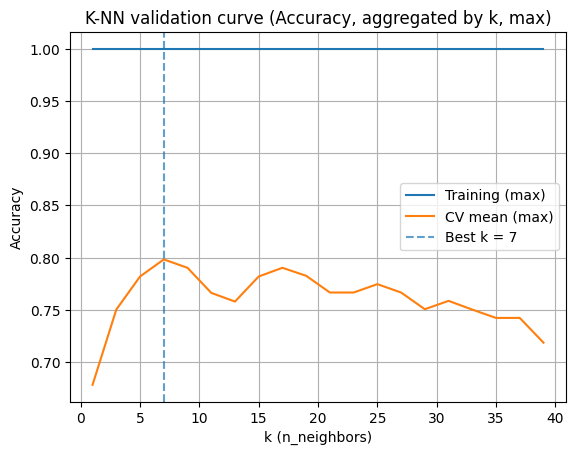

In [8]:
importlib.reload(kc)
kc.plot_knn_validation_curve_from_gs(gs_1)

<h5>Learning Curve</h5>
<p>Learning curve showing the evolution of training and cross-validation accuracy as the size of the training set increases, used to analyze generalization performance and bias–variance characteristics.. Classification accuracy is defined as:
</p>
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\big(\hat{y}_i = y_i\big)$$



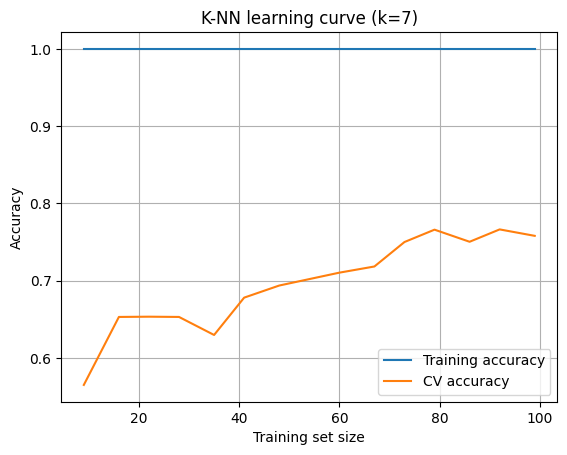

In [9]:
kc.plot_knn_learning_curve(model_1, X_tr_1, y_tr_1, default_cv)

<h5>Learning Curve comparison</h5>
<p>In this plot, we focus on a fixed value of k corresponding to the best k neighbors to analyze the learning dynamics of the KNN classifier. The training accuracy and cross-validation accuracy are plotted as functions of the training set size.
A persistent gap between the curves indicates high variance, while convergence at low accuracy suggests high bias.
</p>

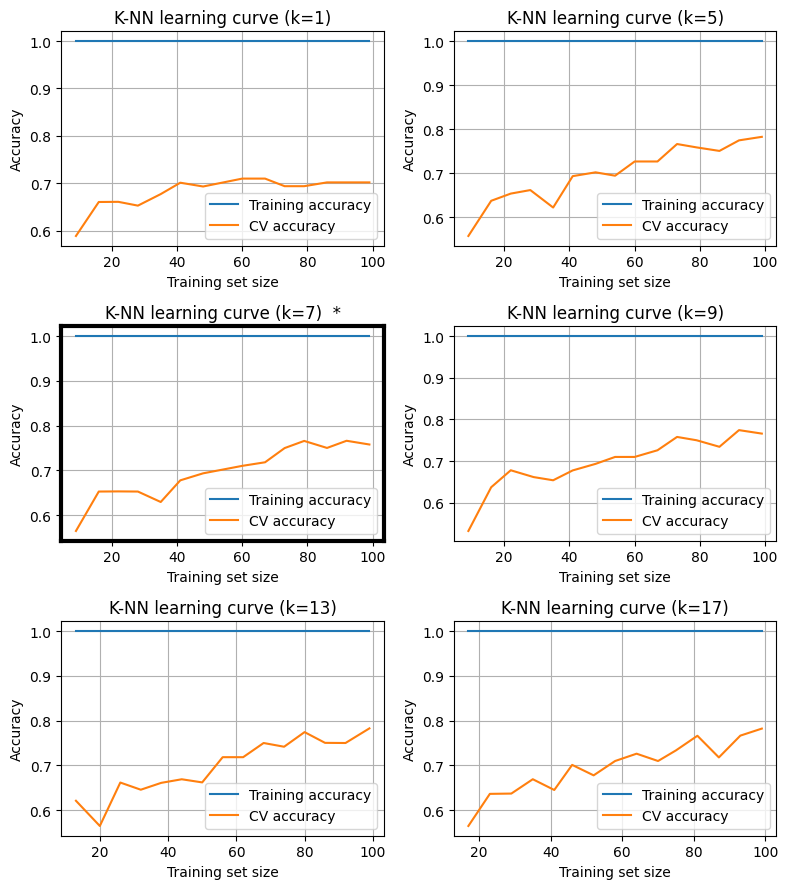

In [10]:
kc.plot_knn_learning_curves_grid(
    model_1,
    X=X_tr_1,
    y=y_tr_1,
    cv=default_cv
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [11]:
# Model has already been fitted by gridsearch
y_ts_1_pred = best_estimator_1.predict(X_ts_1)

In [12]:
import svm_common as sc
cr.assess_cv_robustness(default_cv, best_estimator_1, X_tr_1, y_tr_1, scoring=default_scoring)

seed: 10 - mean 0.774 ± 0.051
seed: 20 - mean 0.790 ± 0.064
seed: 30 - mean 0.806 ± 0.031
seed: 40 - mean 0.806 ± 0.070
seed: 50 - mean 0.823 ± 0.093


In [13]:
print(classification_report(y_ts_1, y_ts_1_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       216
           1       0.88      0.76      0.82       216

    accuracy                           0.83       432
   macro avg       0.84      0.83      0.83       432
weighted avg       0.84      0.83      0.83       432



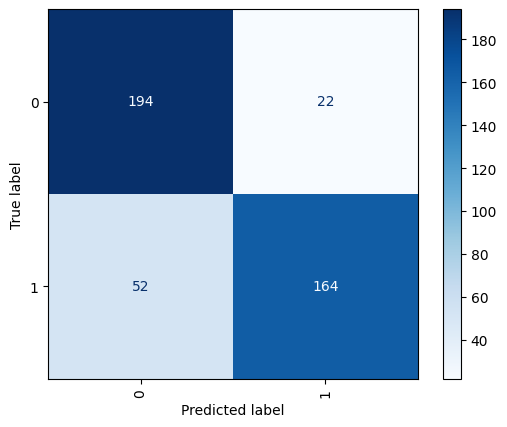

In [14]:
ConfusionMatrixDisplay.from_predictions(y_ts_1, y_ts_1_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 2</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [15]:
monk_2_TR_orig, monk_2_TS_orig = mc.load_set(2)
X_tr_2, y_tr_2 = mc.split_and_prepare_dataset(monk_2_TR_orig)
X_ts_2, y_ts_2 = mc.split_and_prepare_dataset(monk_2_TS_orig)
mc.dataset_introspection(monk_2_TR_orig, monk_2_TS_orig)

,Property,Training,Test
0,Number of samples,169,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 105, class 1 = 64","class 0 = 290, class 1 = 142"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

In [16]:
scoring_2 = "balanced_accuracy" # <- because the dataset show an unbalanced scenario
gs_2 = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=scoring_2,
    cv=default_cv,
    n_jobs=-1,
    return_train_score=True
)

gs_2.fit(X_tr_2, y_tr_2)
best_estimator_2 = gs_2.best_estimator_# Y_train shape: (n_samples, 4)
model_2, best_params = cr.extract_best_pipeline_metrics_from_grid(gs_2)
cr.grid_introspection(gs_2)

Total model explored: 80
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'uniform'}
Best score: 0.6160256410256411
Best model: Pipeline(steps=[('model', KNeighborsClassifier(n_neighbors=21, p=1))])


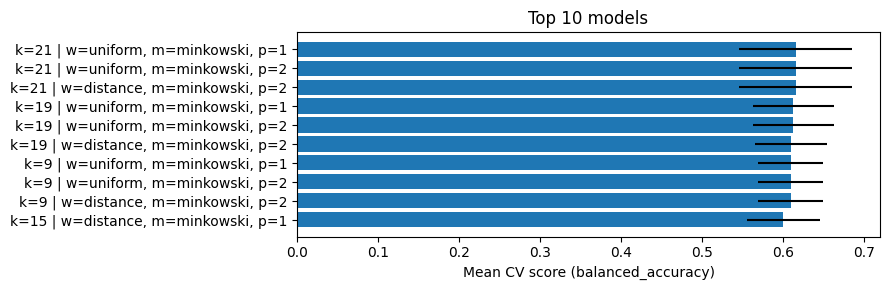

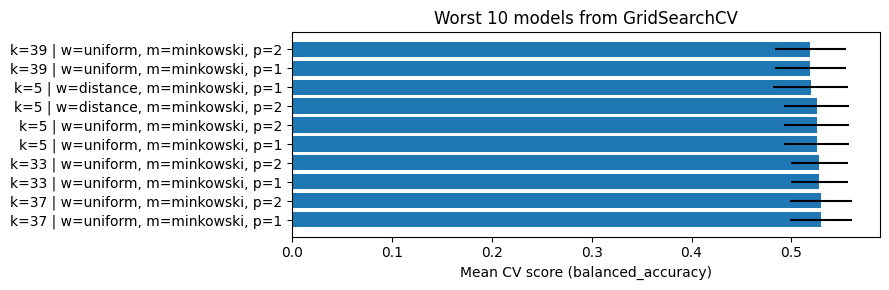

In [17]:
cr.plot_top_models(gs_2.cv_results_, label_row=kc.label_row,scoring_name=scoring_2)

<h5>Validation Curve</h5>
<p>In this plot we analyze the effect of the neighborhood size k on the performance of the K-Nearest Neighbors classifier.
For each value of k, the model accuracy is estimated using cross-validation, allowing us to study how model complexity influences generalization performance.
Formally, accuracy is defined as:
</p>
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\big(\hat{y}_i = y_i\big)$$
<p>
The validation curve highlights the bias–variance trade-off of the KNN classifier as k varies.
</p>

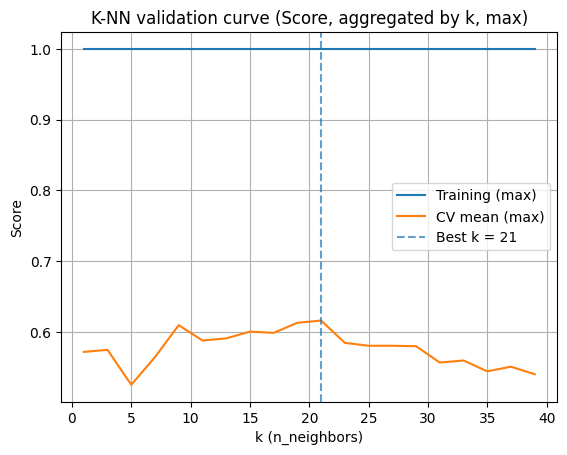

In [18]:
kc.plot_knn_validation_curve_from_gs(gs_2)

<h5>Learning Curve</h5>
<p>Learning curve showing the evolution of training and cross-validation accuracy as the size of the training set increases, used to analyze generalization performance and bias–variance characteristics.. Classification accuracy is defined as:
</p>
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\big(\hat{y}_i = y_i\big)$$



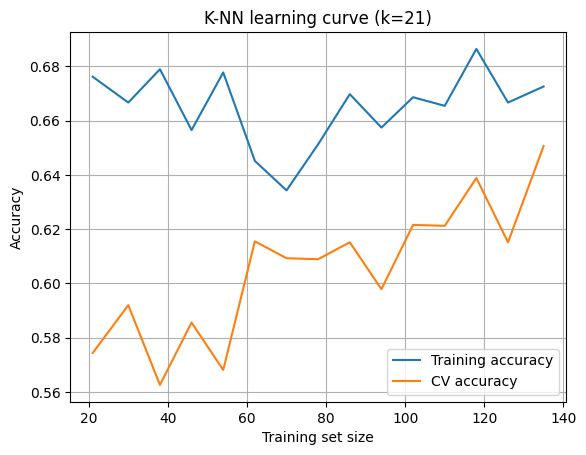

In [19]:
kc.plot_knn_learning_curve(model_2, X_tr_2, y_tr_2, default_cv)

<h5>Learning Curve comparison</h5>
<p>In this plot, we focus on a fixed value of k corresponding to the best k neighbors to analyze the learning dynamics of the KNN classifier. The training accuracy and cross-validation accuracy are plotted as functions of the training set size.
A persistent gap between the curves indicates high variance, while convergence at low accuracy suggests high bias.
</p>

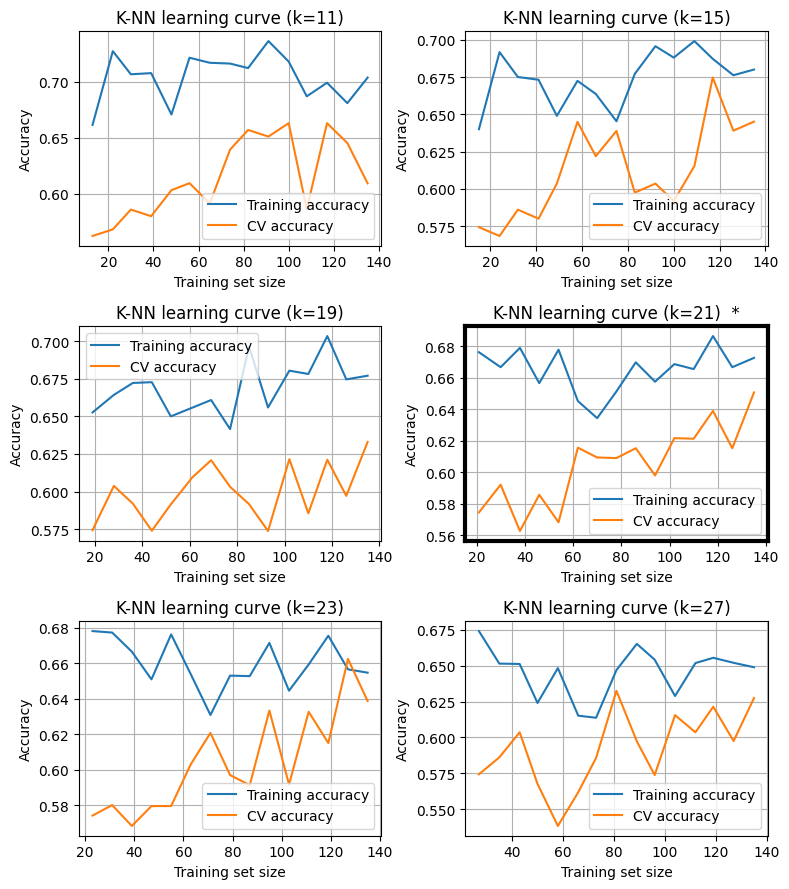

In [20]:
kc.plot_knn_learning_curves_grid(
    model_2,
    X=X_tr_2,
    y=y_tr_2,
    cv=default_cv
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [21]:
# Model has already been fitted by gridsearch
y_ts_pred_2 = best_estimator_2.predict(X_ts_2)

In [22]:
print(classification_report(y_ts_2, y_ts_pred_2, zero_division=0))

              precision    recall  f1-score   support

           0       0.69      0.87      0.77       290
           1       0.43      0.21      0.28       142

    accuracy                           0.65       432
   macro avg       0.56      0.54      0.53       432
weighted avg       0.61      0.65      0.61       432



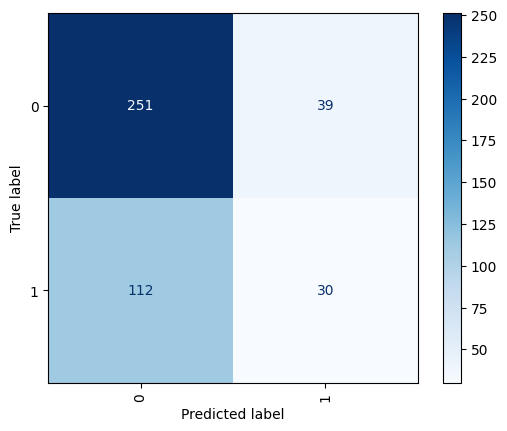

In [23]:
ConfusionMatrixDisplay.from_predictions(y_ts_2, y_ts_pred_2, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 3</h3>
<p></p>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [24]:
monk_3_TR_orig, monk_3_TS_orig = mc.load_set(3)
X_tr_3, y_tr_3 = mc.split_and_prepare_dataset(monk_3_TR_orig)
X_ts_3, y_ts_3 = mc.split_and_prepare_dataset(monk_3_TS_orig)
mc.dataset_introspection(monk_3_TR_orig, monk_3_TS_orig)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


<h4>Model Selection</h4>
<p>Find the best K model.</p>

In [25]:
scoring_3 = "accuracy"
gs_3 = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=scoring_3,
    cv=default_cv,
    n_jobs=-1,
    return_train_score=True
)

gs_3.fit(X_tr_3, y_tr_3)
best_estimator_3 = gs_3.best_estimator_# Y_train shape: (n_samples, 4)
model_3, best_params = cr.extract_best_pipeline_metrics_from_grid(gs_3)
cr.grid_introspection(gs_3)

Total model explored: 80
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 35, 'model__p': 1, 'model__weights': 'distance'}
Best score: 0.9259999999999999
Best model: Pipeline(steps=[('model',
                 KNeighborsClassifier(n_neighbors=35, p=1,
                                      weights='distance'))])


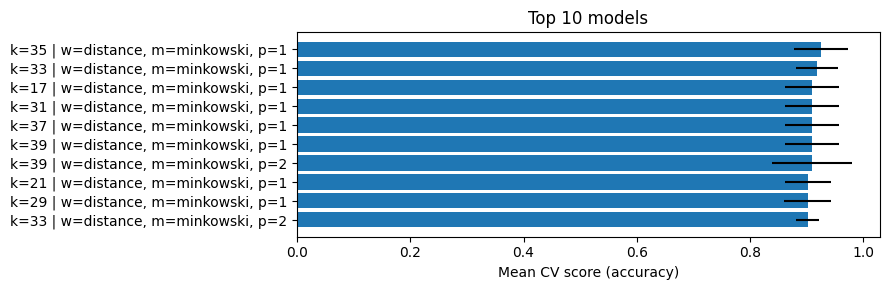

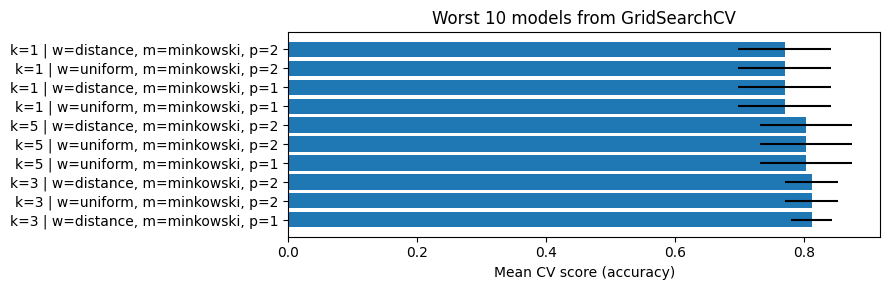

In [26]:
cr.plot_top_models(gs_3.cv_results_, label_row=kc.label_row,scoring_name=scoring_3)

<h5>Validation Curve</h5>
<p>In this plot we analyze the effect of the neighborhood size k on the performance of the K-Nearest Neighbors classifier.
For each value of k, the model accuracy is estimated using cross-validation, allowing us to study how model complexity influences generalization performance.
Formally, accuracy is defined as:
</p>
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\big(\hat{y}_i = y_i\big)$$
<p>
The validation curve highlights the bias–variance trade-off of the KNN classifier as k varies.
</p>

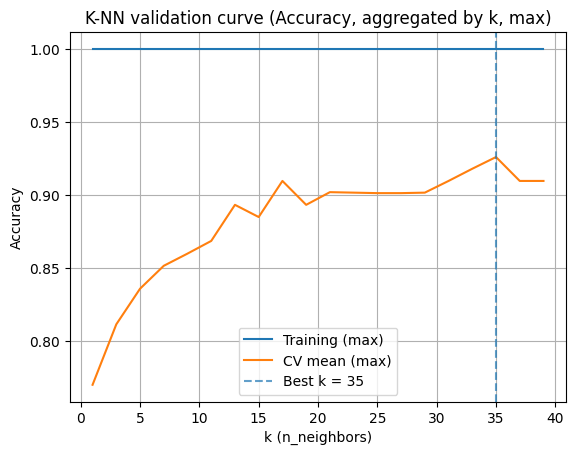

In [27]:
kc.plot_knn_validation_curve_from_gs(gs_3)

<h5>Learning Curve</h5>
<p>Learning curve showing the evolution of training and cross-validation accuracy as the size of the training set increases, used to analyze generalization performance and bias–variance characteristics.. Classification accuracy is defined as:
</p>
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\big(\hat{y}_i = y_i\big)$$



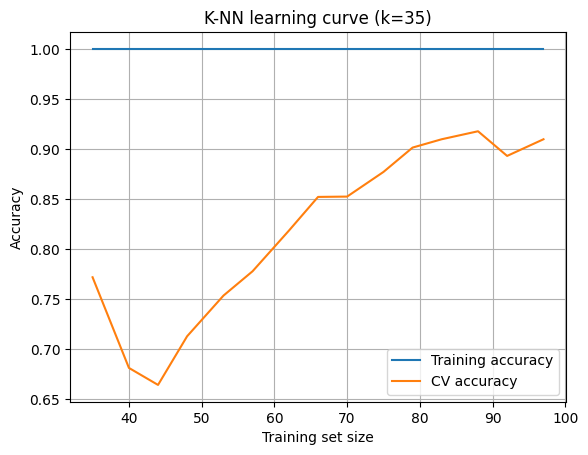

In [28]:
kc.plot_knn_learning_curve(model_3, X_tr_3, y_tr_3, default_cv)

<h5>Learning Curve comparison</h5>
<p>In this plot, we focus on a fixed value of k corresponding to the best k neighbors to analyze the learning dynamics of the KNN classifier. The training accuracy and cross-validation accuracy are plotted as functions of the training set size.
A persistent gap between the curves indicates high variance, while convergence at low accuracy suggests high bias.
</p>

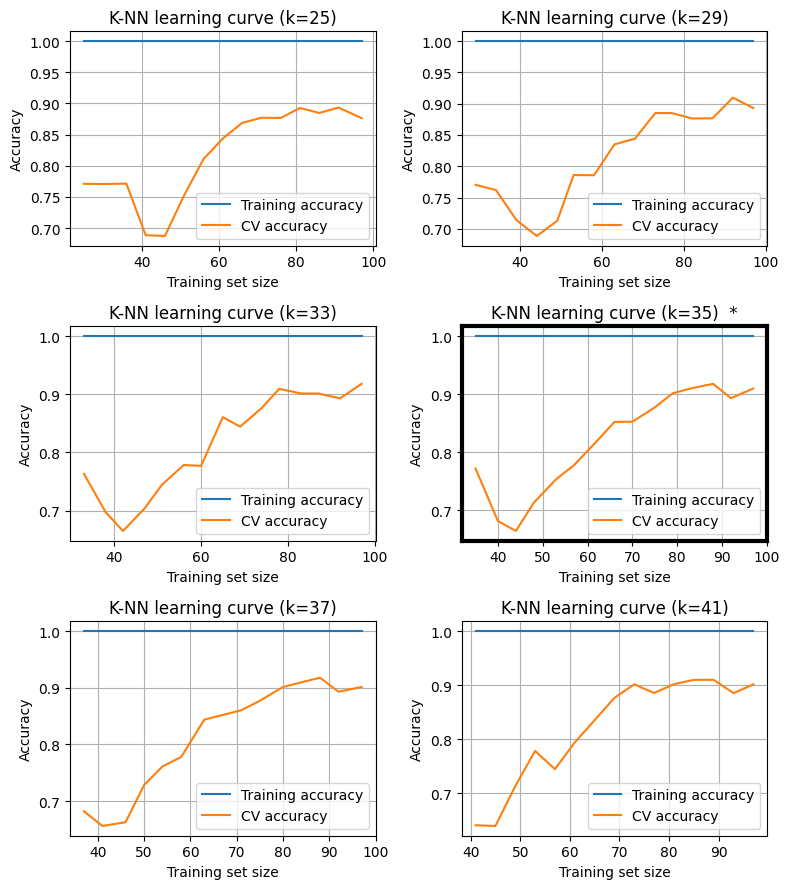

In [29]:
kc.plot_knn_learning_curves_grid(
    model_3,
    X=X_tr_3,
    y=y_tr_3,
    cv=default_cv
)

<h4>Prediction</h4>
<p>Performing a prediction on the test set</p>

In [30]:
# Model has already been fitted by gridsearch
y_ts_3_pred = best_estimator_3.predict(X_ts_3)

In [31]:
print(classification_report(y_ts_3, y_ts_3_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       204
           1       1.00      0.89      0.94       228

    accuracy                           0.94       432
   macro avg       0.94      0.94      0.94       432
weighted avg       0.95      0.94      0.94       432



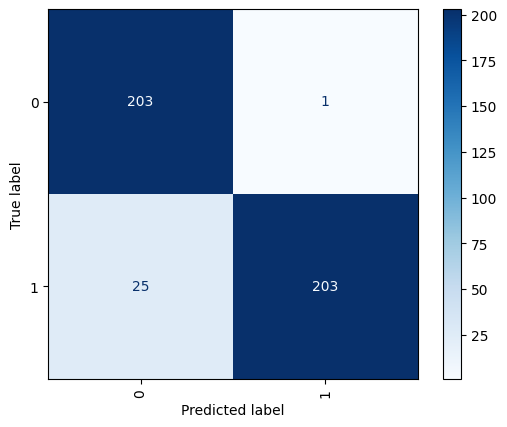

In [32]:
ConfusionMatrixDisplay.from_predictions(y_ts_3, y_ts_3_pred, xticks_rotation='vertical', cmap='Blues');